In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import os

SA_RC = {
    'figure.figsize': (6, 4),
    'figure.dpi': 150,
    'figure.facecolor': 'white',
    'figure.autolayout': True,
    'axes.facecolor': 'white',
    'axes.edgecolor': '#444444',
    'axes.linewidth': 0.8,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.labelsize': 12,
    'axes.labelcolor': 'black',
    'axes.titlelocation': 'center',
    'axes.grid': False,
    'xtick.labelsize': 12,
    'xtick.color': 'black',
    'xtick.direction': 'out',
    'ytick.labelsize': 10,
    'ytick.color': 'black',
    'ytick.direction': 'out',
    'font.family': 'sans-serif',
    'font.serif': ['computer modern roman'],
    'font.sans-serif': ['Helvetica Neue LT Pro'],
    'font.size': 10,
    'text.color': 'black',
    'font.weight': '300',
    'axes.labelweight': '500',
    'patch.edgecolor': 'black',
    'patch.linewidth': 0.7,
    'patch.force_edgecolor': True,
    'legend.fontsize': 8,
    'legend.title_fontsize': 9,
    'legend.framealpha': 0.0,
    'legend.edgecolor': '#444444',
    'lines.linewidth': 0.7,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white',
}
plt.rcParams.update(SA_RC)

ROOT_DIR          = r"D:\pykan\github\workflows\Hyein"
MODEL_DIR_TMPL    = os.path.join(ROOT_DIR, "material_kan_models", "{name_data}")
dir_paper_figure  = os.path.join(ROOT_DIR, "figures_for_paper")
os.makedirs(dir_paper_figure, exist_ok=True)

In [2]:
def combine_log_ratio_maps(data_list, title_map=None, ncols=3,
                           combined_name='log_ratio_maps_combined', save=True):
    """Load log_ratio_map.png for each dataset and combine into a grid figure."""
    n     = len(data_list)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(4.5 * ncols, 4.0 * nrows),
                             constrained_layout=True)
    axes_flat = np.atleast_1d(axes).flatten()

    for ax, name_data in zip(axes_flat, data_list):
        img_path = os.path.join(
            MODEL_DIR_TMPL.format(name_data=name_data),
            f"{name_data}_log_ratio_map.png"
        )
        if not os.path.exists(img_path):
            print(f"[WARNING] Not found: {img_path}")
            ax.text(0.5, 0.5, f"{name_data}\n(not found)",
                    ha='center', va='center', transform=ax.transAxes, fontsize=9)
            ax.axis('off')
            continue

        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.axis('off')
        display_title = (title_map or {}).get(name_data, name_data)
        ax.set_title(display_title, fontsize=11)

    for ax in axes_flat[n:]:
        ax.axis('off')

    if save:
        for ext in ('png', 'svg', 'eps'):
            out = os.path.join(dir_paper_figure, f"{combined_name}.{ext}")
            plt.savefig(out, format=ext if ext != 'png' else None)
            print(f"Saved: {out}")

    plt.show()


Saved: D:\pykan\github\workflows\Hyein\figures_for_paper\log_ratio_maps_combined.png
Saved: D:\pykan\github\workflows\Hyein\figures_for_paper\log_ratio_maps_combined.svg
Saved: D:\pykan\github\workflows\Hyein\figures_for_paper\log_ratio_maps_combined.eps


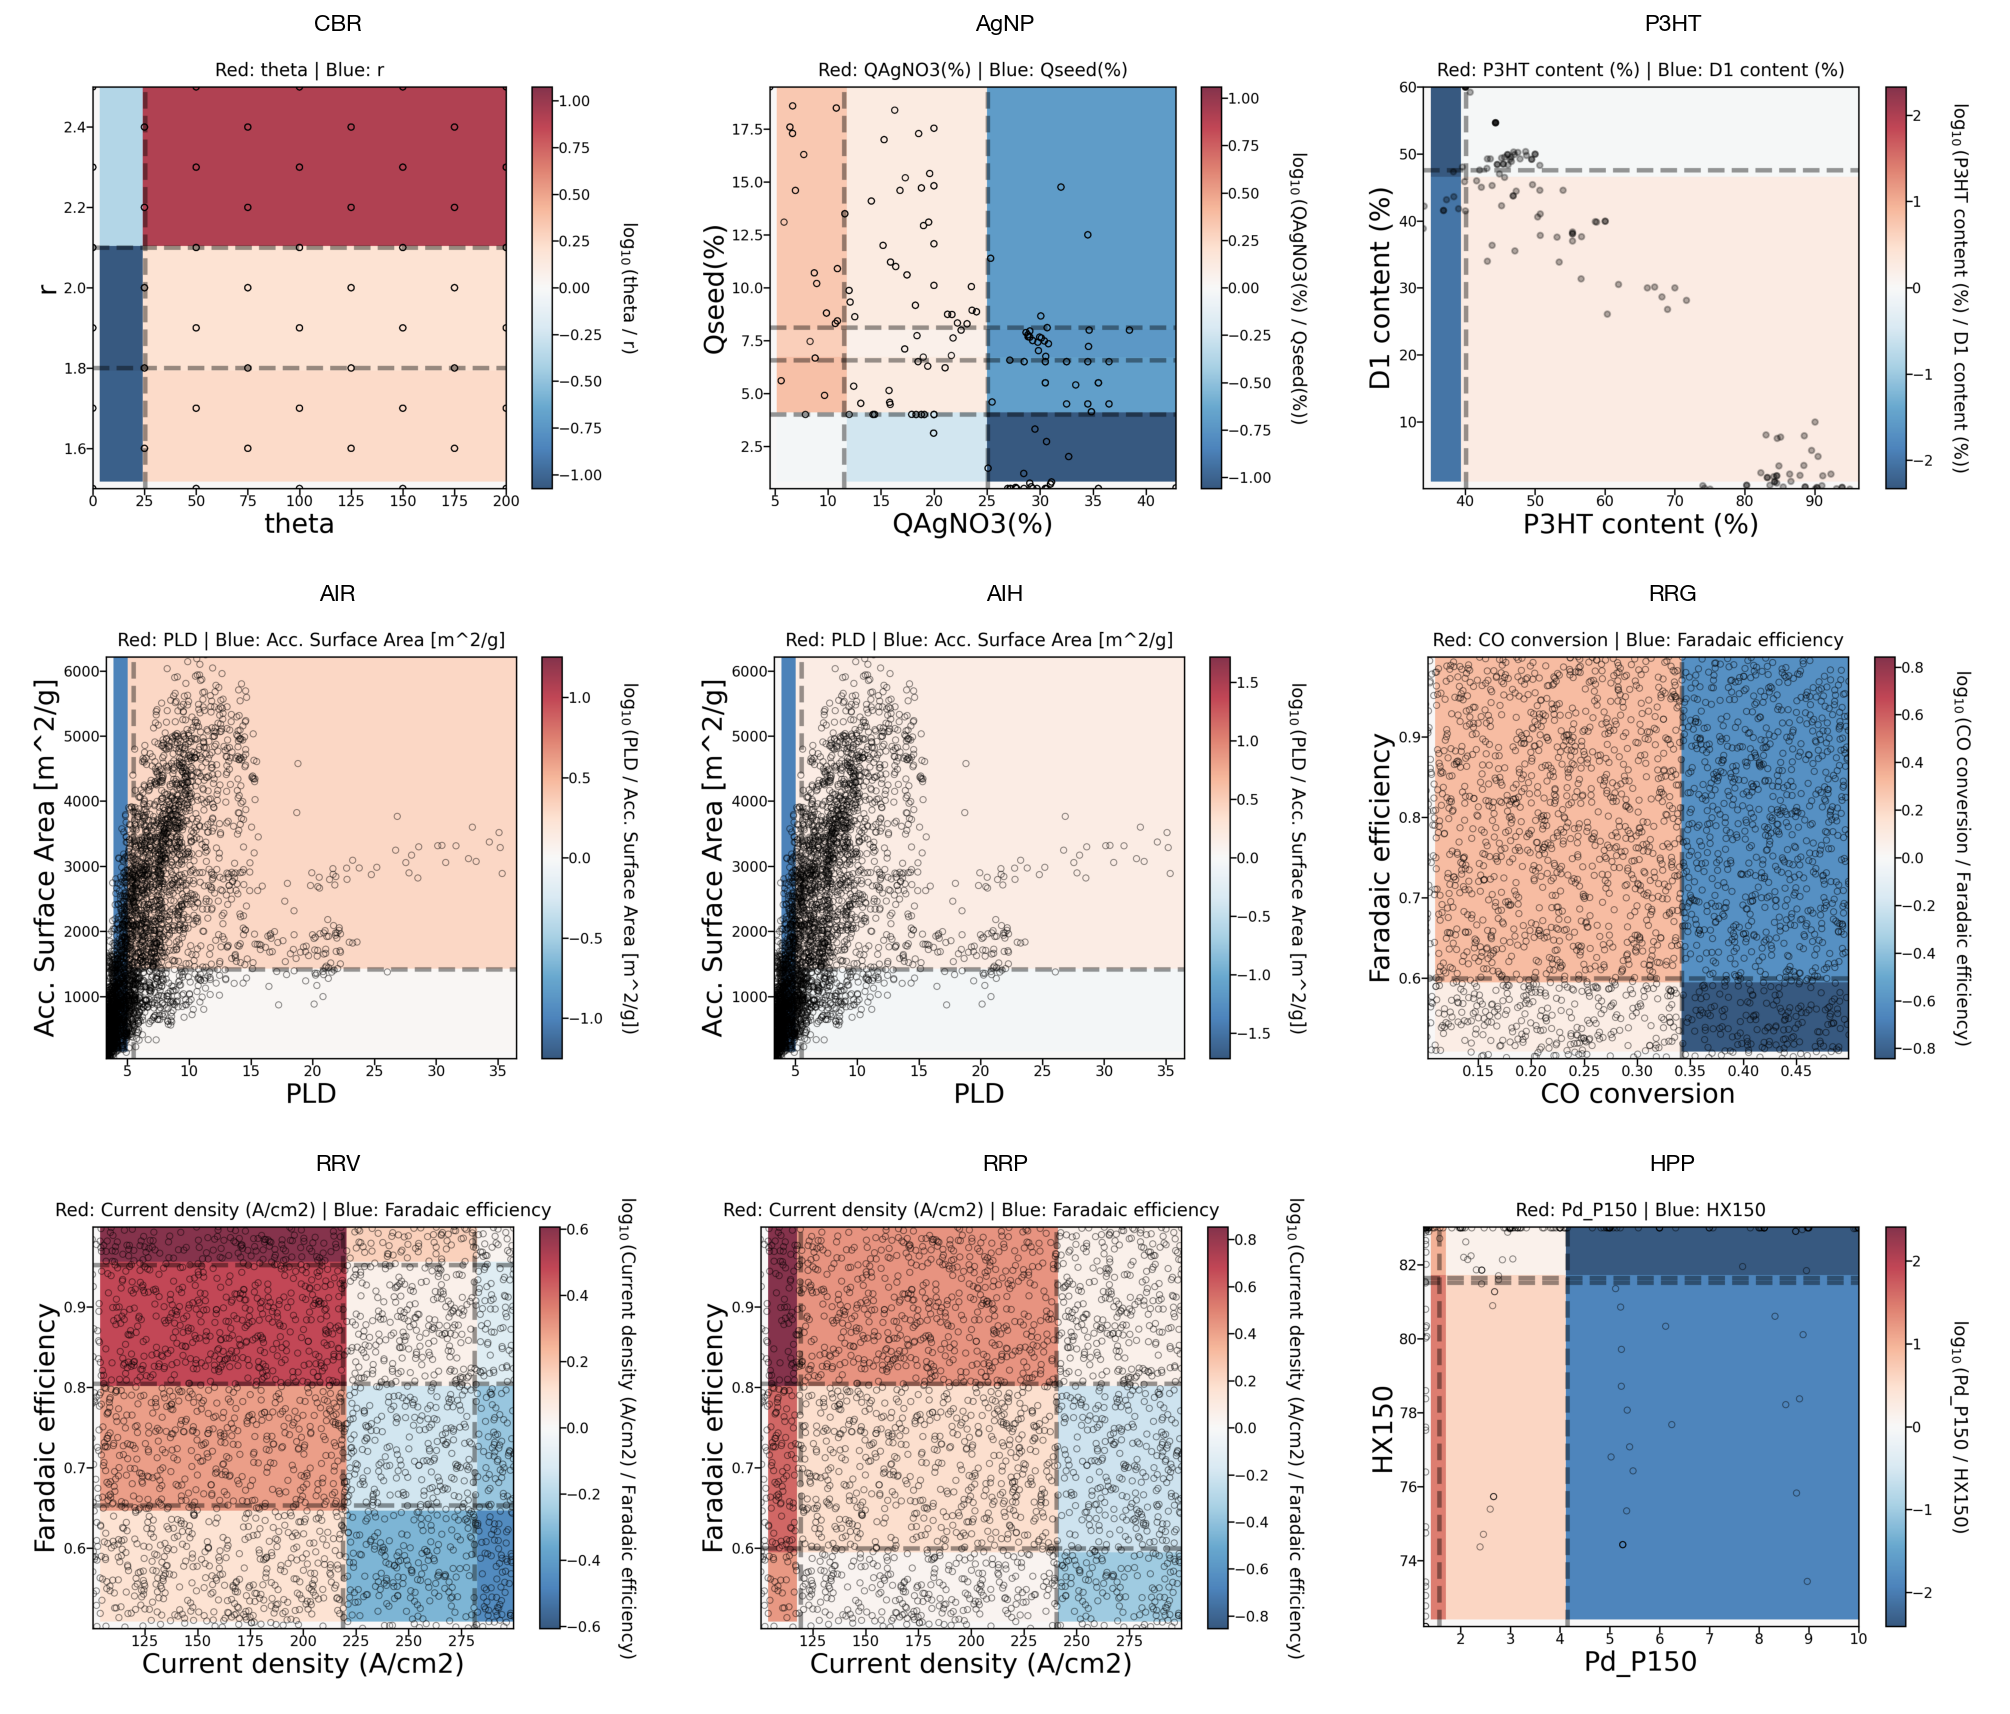

In [7]:
data_list = [
    'CrossedBarrel',
    'AgNP',
    'P3HT',
    'CO2AR4500',
    'CO2AH4500',
    'CO2RRLCA',
    'CO2RRNPV',
    'CO2RRMSP',
    'CO2HPx10',
]

title_map = {
    "CrossedBarrel": "CBR",
    "CO2AR4500": "AIR",
    "CO2AH4500": "AIH",
    "CO2RRNPV": "RRV",
    "CO2RRMSP": "RRP",
    "CO2RRLCA": "RRG",
    "CO2HPx10": "HPP",
}
combine_log_ratio_maps(data_list, title_map=title_map,
                       ncols=3, combined_name='log_ratio_maps_combined')